<div style="
background-color:#EAEAEA;
padding:15px;
border-left:5px solid #6C757D;
border-radius:6px;">

# Master's Thesis in Advanced Physics
---

This notebook is part of the **Master's Thesis (MSc Dissertation)**: **Fast Simulation of Neutrino Oscillations in Matter**.

**Author**
Juan Ramon Diaz Santos <diazjuan@alumni.uv.es>

**Supervisors**
Roberto Ruiz de Austri Bazan <rruiz@ific.uv.es>
Michele Lucente <michele.lucente@unibo.it>

**Date**
June 2026
</div>

# Core Diagnostic 6 - NuFIT Oscillation Preset Comparison
---

This notebook visualizes, analyses, and compares the three **standard 3-flavour
SM NuFIT presets** registered in `tpeanuts.core.common.presets.OSCILLATION_PRESETS`:
`_SM_NUFIT52_NO`, `_SM_NUFIT60_NO`, and `_SM_NUFIT61_NO`, corresponding to the
NuFIT 5.2 (2022), 6.0 (2024), and 6.1 (2025) global fits to neutrino
oscillation data, all Normal Ordering with Super-Kamiokande atmospheric data
included. Only these three plain-SM presets are covered here -- not the
`_LMA_DARK_NUFIT52_NO` degenerate-solution preset or the sterile presets that
happen to inherit the NuFIT 5.2 SM sector, since those answer different
questions.

The notebook is intentionally diagnostic rather than a pytest suite: it exists
to make the numeric differences between preset generations, and their
downstream physical impact through `medium.vacuum.probability`, directly
visible.

---

## Table of Contents

| # | Section |
|---|---------|
| [0](#0.-Theory-Background) | **Theory Background**: what NuFIT is, the three presets, what changed and why |
| [1](#1.-Libraries) | **Libraries** |
| [2](#2.-Paths-and-Configuration) | **Paths and Configuration** |
| [3](#3.-Mixing-Angles-and-CP-Phase-Across-Generations) | **Mixing Angles and CP Phase Across Generations** |
| [4](#4.-Mass-Squared-Splittings-Across-Generations) | **Mass-Squared Splittings Across Generations** |
| [5](#5.-PMNS-Matrix-Comparison) | **PMNS Matrix Comparison**: $|U_{\alpha i}|^2$ per generation |
| [6](#6.-Vacuum-Oscillation-Probability-Impact) | **Vacuum Oscillation Probability Impact** |
| [7](#7.-Jarlskog-Invariant-Across-Generations) | **Jarlskog Invariant Across Generations** |
| [8](#8.-Summary) | **Summary** |


## 0. Theory Background

### 0.1 What NuFIT Is

[NuFIT](http://www.nu-fit.org) (Esteban, Gonzalez-Garcia, Maltoni,
Martinez-Soler, Schwetz, and collaborators) is a running global fit of all
publicly available neutrino oscillation data -- solar (Homestake, GALLEX/
SAGE, Super-Kamiokande, SNO, Borexino), atmospheric (Super-Kamiokande,
IceCube/DeepCore), reactor (KamLAND, Daya Bay, RENO, Double Chooz, SNO+,
JUNO), and long-baseline accelerator (T2K, NOvA) experiments -- to the
standard three-flavour mixing parameters $(\theta_{12},\theta_{13},\theta_{23},
\delta_{CP},\Delta m^2_{21},\Delta m^2_{3\ell})$. New data releases prompt
periodic re-fits, each published as a new NuFIT version with an updated best
fit and uncertainty.

### 0.2 The Three Preset Generations

| Preset | NuFIT version | Data cutoff | Key new ingredient |
|---|---|---|---|
| `_SM_NUFIT52_NO` | 5.2 | November 2022 | -- |
| `_SM_NUFIT60_NO` | 6.0 | September 2024 | Updated SK-atm/IceCube atmospheric $\chi^2$ tables, Daya Bay reactor flux update, first SNO+ inclusion |
| `_SM_NUFIT61_NO` | 6.1 | November 2025 | First inclusion of JUNO's initial $\theta_{12}$/$\Delta m^2_{21}$ measurement |

All three are the "Normal Ordering, best fit, with Super-Kamiokande
atmospheric data" row of their respective official parameter tables
(`nu-fit.org`), matching the convention already used for `_SM_NUFIT52_NO`.

### 0.3 What Changed, and Why It Matters

Two changes across these three generations are large enough to matter for
this thesis's own simulations, not just as a numerical curiosity:

- **$\theta_{23}$ dropped from $49.0°$ (5.2) to $\sim43.3°$ (6.0, 6.1)** --
  a shift of nearly $6°$, moving the atmospheric mixing angle from the
  second octant ($\theta_{23}>45°$) to close to (just below) maximal mixing.
  This directly rescales every atmospheric- and long-baseline-sensitive
  oscillation probability computed with `medium.vacuum`/`medium.earth`.
- **$\Delta m^2_{21}$ increased by JUNO's inclusion**, from
  $7.41\times10^{-5}$ (5.2) through $7.49\times10^{-5}$ (6.0) to
  $7.537\times10^{-5}\,\mathrm{eV}^2$ (6.1) -- a cumulative $\sim1.7\%$ shift,
  small in relative terms but directly visible once JUNO-precision reactor
  data start to matter for solar-sector observables.

$\theta_{12}$, $\theta_{13}$, and $\delta_{CP}$ move by comparatively small
amounts across the same span. Section 6 shows what these shifts actually do
to a computed oscillation probability, rather than leaving the comparison at
the level of tabulated numbers.

### References

- I. Esteban, M. C. Gonzalez-Garcia, M. Maltoni, T. Schwetz, A. Zhou,
  **The fate of hints: updated global analysis of three-flavor neutrino
  oscillations**, *JHEP* **09**, 178 (2020), arXiv:
  [2007.14792](https://arxiv.org/abs/2007.14792). (NuFIT 5.0/5.1 methodology)
- I. Esteban, M. C. Gonzalez-Garcia, M. Maltoni, J. P. Pinheiro, T. Schwetz,
  **NuFIT-6.0: Updated global analysis of three-flavor neutrino
  oscillations**, *JHEP* **12**, 216 (2024), DOI:
  [10.1007/JHEP12(2024)216](https://doi.org/10.1007/JHEP12(2024)216), arXiv:
  [2410.05380](https://arxiv.org/abs/2410.05380). (NuFIT 6.0 and, per the
  citation instructions on the NuFIT results page, also the base analysis
  for the NuFIT 6.1 (2025) website update)
- Dataset: [www.nu-fit.org](http://www.nu-fit.org), results pages for v5.2
  (node/256), v6.0 (node/294), and v6.1 (node/309), accessed for this thesis.


## 1. Libraries

In [1]:
import math

import numpy as np
import torch
import matplotlib.pyplot as plt

from tpeanuts.core.common.oscillation import OscillationParameters
from tpeanuts.core.common.presets import OSCILLATION_PRESETS
from tpeanuts.medium.vacuum.probability import pvacuum, vacuum_probability
from tpeanuts.notebooks.notebookConfig import load_notebook_config
from tpeanuts.notebooks.notebooks_helper import save_and_show, to_numpy
from tpeanuts.util.context import RuntimeContext

print(f"Torch {torch.__version__}")

Torch 2.3.1


## 2. Paths and Configuration

### 2.1 Paths

`load_notebook_config()` resolves the repository root, applies the shared
plotting style, and provides the common output root. The output directory is
built from the notebook path relative to `notebooks/`, excluding the
notebook filename: `diagnostic/core`.

**Expected results:** the three presets should be found in
`OSCILLATION_PRESETS` and build without error.

In [2]:
config = load_notebook_config()
ctx = RuntimeContext.resolve(config.device, config.dtype)
OUTPUT_DIR = config.output_dir("diagnostic", "core")

PRESET_NAMES = ["_SM_NUFIT52_NO", "_SM_NUFIT60_NO", "_SM_NUFIT61_NO"]
PRESET_LABELS = {"_SM_NUFIT52_NO": "NuFIT 5.2 (2022)", "_SM_NUFIT60_NO": "NuFIT 6.0 (2024)", "_SM_NUFIT61_NO": "NuFIT 6.1 (2025)"}
PRESET_COLORS = {"_SM_NUFIT52_NO": "C0", "_SM_NUFIT60_NO": "C1", "_SM_NUFIT61_NO": "C2"}

oscillations = {name: OscillationParameters.from_preset(name, context=ctx) for name in PRESET_NAMES}

print(f"Package dir : {config.package_dir}")
print(f"Output dir  : {OUTPUT_DIR}")
print(f"Device      : {ctx.device}   dtype: {ctx.dtype}")
for name in PRESET_NAMES:
    raw = OSCILLATION_PRESETS[name]
    print(f"{PRESET_LABELS[name]:16s} theta12={raw['theta12_deg']:.2f} theta13={raw['theta13_deg']:.2f} "
          f"theta23={raw['theta23_deg']:.2f} delta={raw['delta13_deg']:.1f} "
          f"DM21={raw['DeltamSq21']:.3e} DM3l={raw['DeltamSq3l']:+.3e}")

Package dir : G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts
Output dir  : v:\output\diagnostic\core
Device      : cpu   dtype: torch.float64
NuFIT 5.2 (2022) theta12=33.41 theta13=8.58 theta23=49.00 delta=197.0 DM21=7.410e-05 DM3l=+2.511e-03
NuFIT 6.0 (2024) theta12=33.68 theta13=8.56 theta23=43.30 delta=212.0 DM21=7.490e-05 DM3l=+2.513e-03
NuFIT 6.1 (2025) theta12=33.76 theta13=8.62 theta23=43.29 delta=212.0 DM21=7.537e-05 DM3l=+2.511e-03


## 3. Mixing Angles and CP Phase Across Generations

Each angle and the CP phase, compared across the three preset generations.
The $\pm1\sigma$ error bars are the official NuFIT uncertainties for the
"Normal Ordering, with SK atmospheric data" row (not stored in the preset
registry itself, since it only carries central values; reproduced here from
the same official tables for context).

**Expected results:** $\theta_{23}$ should show the large 5.2-to-6.0 drop
described in Section 0.3; $\theta_{12}$ should show a small but visible
6.0-to-6.1 shift (the JUNO effect); $\theta_{13}$ and $\delta_{CP}$ should be
comparatively stable.

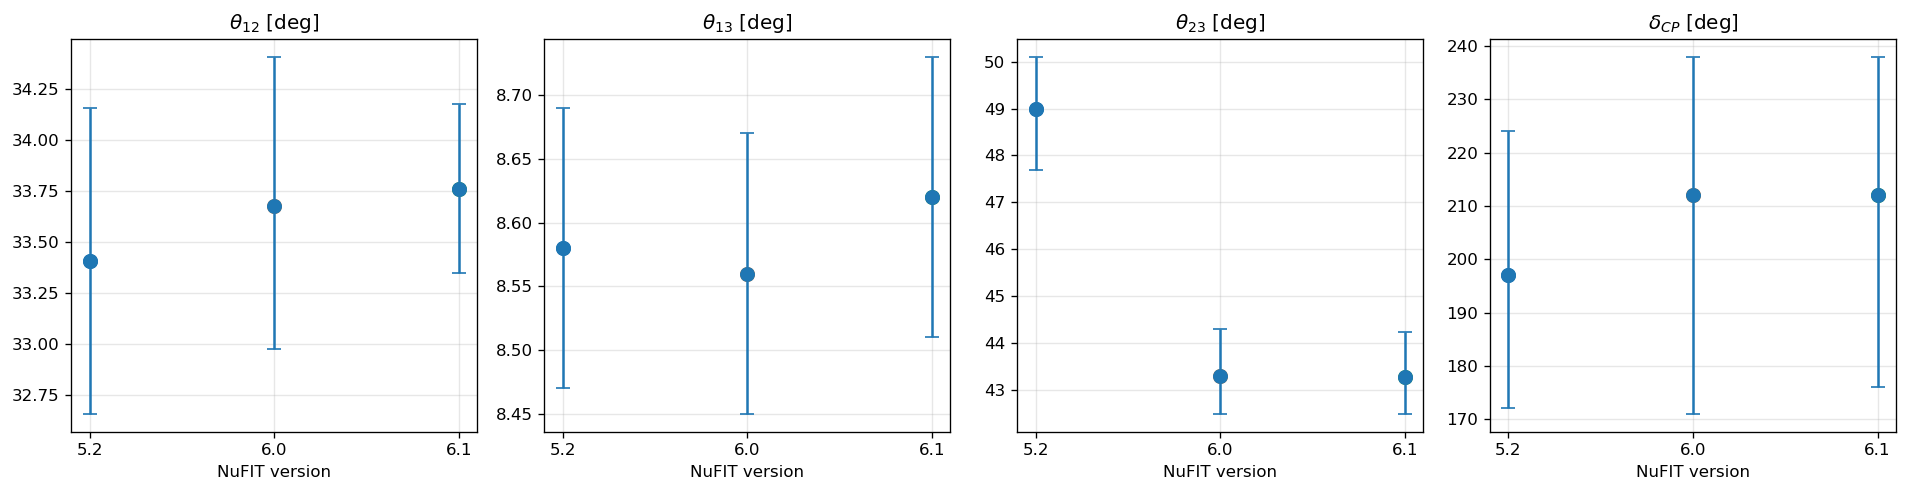

v:\output\diagnostic\core\diagnostic6_fig3_angles_vs_generation.png
theta23 shift, 5.2 -> 6.0: -5.70 deg
theta12 shift, 6.0 -> 6.1 (JUNO): +0.08 deg


In [3]:
# (bfp, -1sigma, +1sigma) per generation, "with SK atmospheric data", NO best fit.
# Source: official NuFIT parameter-range tables (see Section 0 references).
ANGLE_ERRORS_DEG = {
    "theta12": {"_SM_NUFIT52_NO": (33.41, 0.75, 0.75), "_SM_NUFIT60_NO": (33.68, 0.70, 0.73), "_SM_NUFIT61_NO": (33.76, 0.41, 0.42)},
    "theta13": {"_SM_NUFIT52_NO": (8.58, 0.11, 0.11), "_SM_NUFIT60_NO": (8.56, 0.11, 0.11), "_SM_NUFIT61_NO": (8.62, 0.11, 0.11)},
    "theta23": {"_SM_NUFIT52_NO": (49.0, 1.3, 1.1), "_SM_NUFIT60_NO": (43.3, 0.8, 1.0), "_SM_NUFIT61_NO": (43.29, 0.79, 0.96)},
    "delta13": {"_SM_NUFIT52_NO": (197.0, 25.0, 27.0), "_SM_NUFIT60_NO": (212.0, 41.0, 26.0), "_SM_NUFIT61_NO": (212.0, 36.0, 26.0)},
}

fig, axes = plt.subplots(1, 4, figsize=(16.0, 4.2))
x = np.arange(len(PRESET_NAMES))

for ax, (param, label) in zip(axes, [("theta12", r"$\theta_{12}$"), ("theta13", r"$\theta_{13}$"), ("theta23", r"$\theta_{23}$"), ("delta13", r"$\delta_{CP}$")]):
    values = [ANGLE_ERRORS_DEG[param][name][0] for name in PRESET_NAMES]
    lo = [ANGLE_ERRORS_DEG[param][name][1] for name in PRESET_NAMES]
    hi = [ANGLE_ERRORS_DEG[param][name][2] for name in PRESET_NAMES]
    ax.errorbar(x, values, yerr=[lo, hi], fmt="o", ms=8, capsize=4,
                color=[PRESET_COLORS[n] for n in PRESET_NAMES][0])
    for xi, name in zip(x, PRESET_NAMES):
        ax.plot(xi, ANGLE_ERRORS_DEG[param][name][0], "o", ms=8, color=PRESET_COLORS[name])
    ax.set_xticks(x)
    ax.set_xticklabels(["5.2", "6.0", "6.1"])
    ax.set_xlabel("NuFIT version")
    ax.set_title(f"{label} [deg]")
    ax.grid(True, alpha=0.3)

fig.tight_layout()
save_and_show("diagnostic6_fig3_angles_vs_generation.png", fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

theta23_shift = ANGLE_ERRORS_DEG["theta23"]["_SM_NUFIT60_NO"][0] - ANGLE_ERRORS_DEG["theta23"]["_SM_NUFIT52_NO"][0]
theta12_shift = ANGLE_ERRORS_DEG["theta12"]["_SM_NUFIT61_NO"][0] - ANGLE_ERRORS_DEG["theta12"]["_SM_NUFIT60_NO"][0]
print(f"theta23 shift, 5.2 -> 6.0: {theta23_shift:+.2f} deg")
print(f"theta12 shift, 6.0 -> 6.1 (JUNO): {theta12_shift:+.2f} deg")

## 4. Mass-Squared Splittings Across Generations

**Expected results:** $\Delta m^2_{21}$ should show a small but monotonic
increase across the three generations (most visibly 6.0 to 6.1, the JUNO
effect); $\Delta m^2_{3\ell}$ should stay comparatively flat.

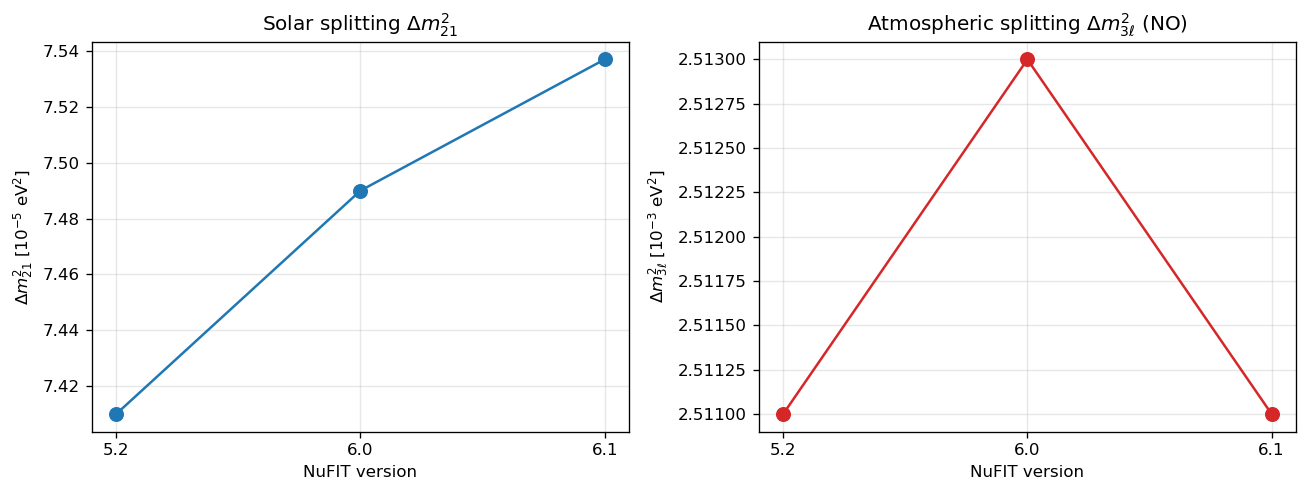

v:\output\diagnostic\core\diagnostic6_fig4_mass_splittings_vs_generation.png
Delta m^2_21, 5.2 -> 6.1 relative shift: +1.7139%
Delta m^2_3l range across generations  : [2.5110e-03, 2.5130e-03] eV^2


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.2))

dm21 = [float(oscillations[n].DeltamSq21) for n in PRESET_NAMES]
dm3l = [float(oscillations[n].DeltamSq3l) for n in PRESET_NAMES]

axes[0].plot(x, np.array(dm21) * 1.0e5, "o-", ms=8)
axes[0].set_ylabel(r"$\Delta m^2_{21}$ [$10^{-5}$ eV$^2$]")
axes[0].set_title(r"Solar splitting $\Delta m^2_{21}$")

axes[1].plot(x, np.array(dm3l) * 1.0e3, "o-", ms=8, color="C3")
axes[1].set_ylabel(r"$\Delta m^2_{3\ell}$ [$10^{-3}$ eV$^2$]")
axes[1].set_title(r"Atmospheric splitting $\Delta m^2_{3\ell}$ (NO)")

for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(["5.2", "6.0", "6.1"])
    ax.set_xlabel("NuFIT version")
    ax.grid(True, alpha=0.3)

fig.tight_layout()
save_and_show("diagnostic6_fig4_mass_splittings_vs_generation.png", fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

rel_shift_dm21 = (dm21[-1] - dm21[0]) / dm21[0]
print(f"Delta m^2_21, 5.2 -> 6.1 relative shift: {rel_shift_dm21:+.4%}")
print(f"Delta m^2_3l range across generations  : [{min(dm3l):.4e}, {max(dm3l):.4e}] eV^2")

## 5. PMNS Matrix Comparison

The full $|U_{\alpha i}|^2$ flavour-content matrix for each generation,
built via `oscillation.pmns.pmns_matrix()`.

**Expected results:** the electron row ($|U_{e i}|^2$) should be nearly
identical across generations (it depends only on $\theta_{12}$,
$\theta_{13}$, both fairly stable); the $\mu$/$\tau$ rows should visibly
reshuffle between 5.2 and 6.0/6.1, tracking the $\theta_{23}$ shift.

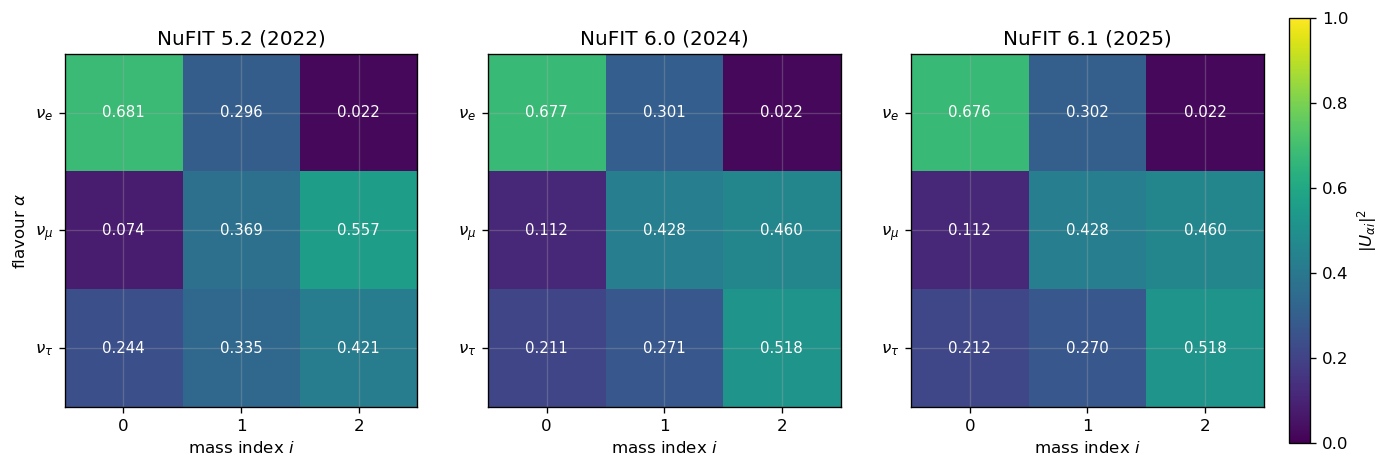

v:\output\diagnostic\core\diagnostic6_fig5_pmns_matrix_comparison.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.6))

for ax, name in zip(axes, PRESET_NAMES):
    U = oscillations[name].pmns.pmns_matrix()
    P = to_numpy(torch.abs(U) ** 2)
    image = ax.imshow(P, vmin=0.0, vmax=1.0, cmap="viridis")
    ax.set_title(PRESET_LABELS[name])
    ax.set_xlabel("mass index $i$")
    ax.set_xticks([0, 1, 2])
    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels([r"$\nu_e$", r"$\nu_\mu$", r"$\nu_\tau$"])
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f"{P[i, j]:.3f}", ha="center", va="center", color="white", fontsize=9)

axes[0].set_ylabel("flavour $\\alpha$")
fig.colorbar(image, ax=axes, label=r"$|U_{\alpha i}|^2$", fraction=0.025, pad=0.02)
save_and_show("diagnostic6_fig5_pmns_matrix_comparison.png", fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

## 6. Vacuum Oscillation Probability Impact

To make the parameter shifts of Section 3 concrete, `pvacuum` is evaluated
for a coherent initial $\nu_\mu$ state at a DUNE-like long baseline
($L=1300$ km) across a broad energy range, for all three presets.

**Expected results:** the NuFIT 5.2 curve should visibly differ from the
6.0/6.1 curves (tracking the $\theta_{23}$ shift, which controls the
overall depth of $\nu_\mu$ disappearance and $\nu_\mu\to\nu_e$ appearance
amplitude); the 6.0 and 6.1 curves should sit close to each other.

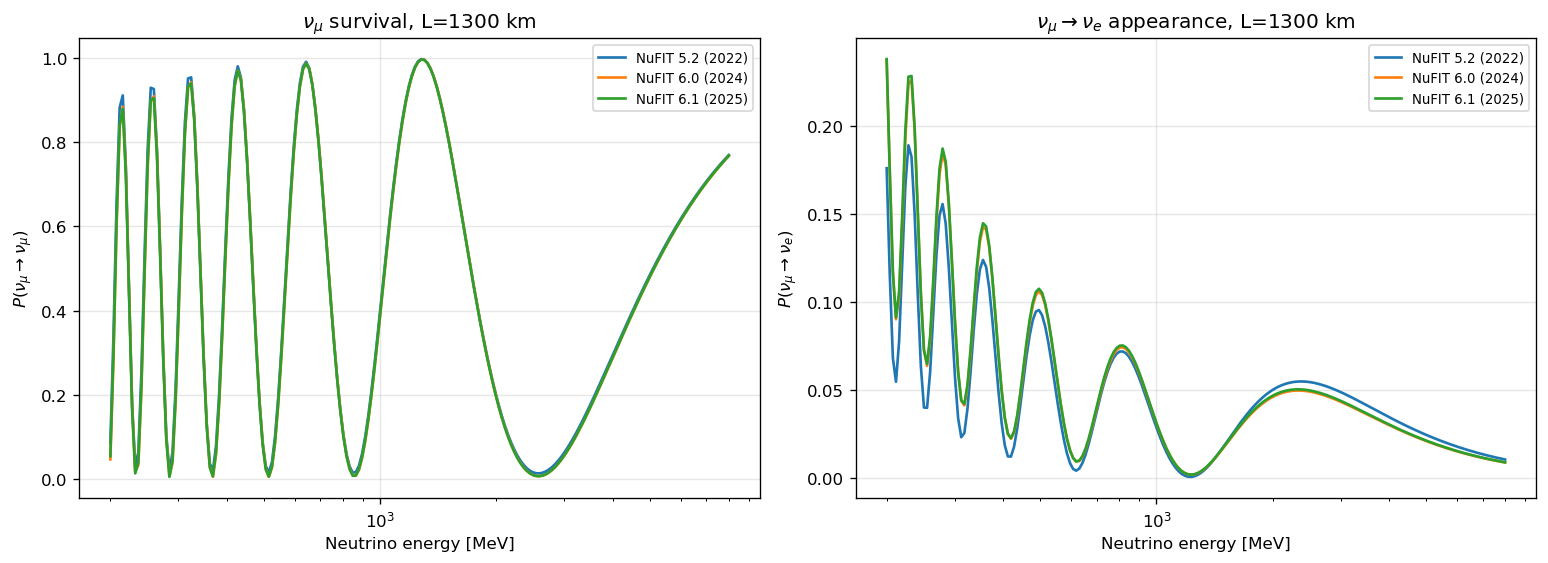

v:\output\diagnostic\core\diagnostic6_fig6_vacuum_probability_impact.png
NuFIT 5.2 (2022): P(mu->mu)=0.1967  P(mu->e)=0.0501  (E=2000 MeV, L=1300 km)
NuFIT 6.0 (2024): P(mu->mu)=0.1939  P(mu->e)=0.0461  (E=2000 MeV, L=1300 km)
NuFIT 6.1 (2025): P(mu->mu)=0.1925  P(mu->e)=0.0468  (E=2000 MeV, L=1300 km)


In [6]:
L_FIXED = 1300.0
E_grid = torch.logspace(math.log10(200.0), math.log10(8000.0), 200, device=ctx.device, dtype=ctx.dtype)
initial_mu = torch.tensor([0.0, 1.0, 0.0], device=ctx.device, dtype=torch.complex128)

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.8), sharex=True)

for name in PRESET_NAMES:
    P = pvacuum(initial_mu, oscillations[name], E_grid, torch.tensor(L_FIXED, device=ctx.device, dtype=ctx.dtype), massbasis=False, context=ctx)
    axes[0].plot(to_numpy(E_grid), to_numpy(P[:, 1]), color=PRESET_COLORS[name], lw=1.6, label=PRESET_LABELS[name])
    axes[1].plot(to_numpy(E_grid), to_numpy(P[:, 0]), color=PRESET_COLORS[name], lw=1.6, label=PRESET_LABELS[name])

axes[0].set_xscale("log")
axes[1].set_xscale("log")
axes[0].set_ylabel(r"$P(\nu_\mu\to\nu_\mu)$")
axes[1].set_ylabel(r"$P(\nu_\mu\to\nu_e)$")
axes[0].set_title(r"$\nu_\mu$ survival, L=1300 km")
axes[1].set_title(r"$\nu_\mu\to\nu_e$ appearance, L=1300 km")
for ax in axes:
    ax.set_xlabel("Neutrino energy [MeV]")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

fig.tight_layout()
save_and_show("diagnostic6_fig6_vacuum_probability_impact.png", fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

E_ref = torch.tensor(2000.0, device=ctx.device, dtype=ctx.dtype)
L_ref = torch.tensor(L_FIXED, device=ctx.device, dtype=ctx.dtype)
for name in PRESET_NAMES:
    P = pvacuum(initial_mu, oscillations[name], E_ref, L_ref, massbasis=False, context=ctx)
    print(f"{PRESET_LABELS[name]:16s}: P(mu->mu)={float(P[1]):.4f}  P(mu->e)={float(P[0]):.4f}  (E=2000 MeV, L=1300 km)")

## 7. Jarlskog Invariant Across Generations

$$
J = \mathrm{Im}\left(U_{e1}U_{\mu2}U_{e2}^*U_{\mu1}^*\right)
  = \frac{1}{8}\sin2\theta_{12}\sin2\theta_{13}\sin2\theta_{23}\cos\theta_{13}\sin\delta_{CP}.
$$

**Expected results:** since $\theta_{23}$ dropped from $49°$ (second octant)
toward $\sim43°$ (close to but below maximal, $45°$) between 5.2 and 6.0/6.1,
$\sin2\theta_{23}$ actually changes only mildly (it is symmetric around
$45°$); the dominant shift in $J$ should instead track $\delta_{CP}$ moving
from $197°$ to $212°$.

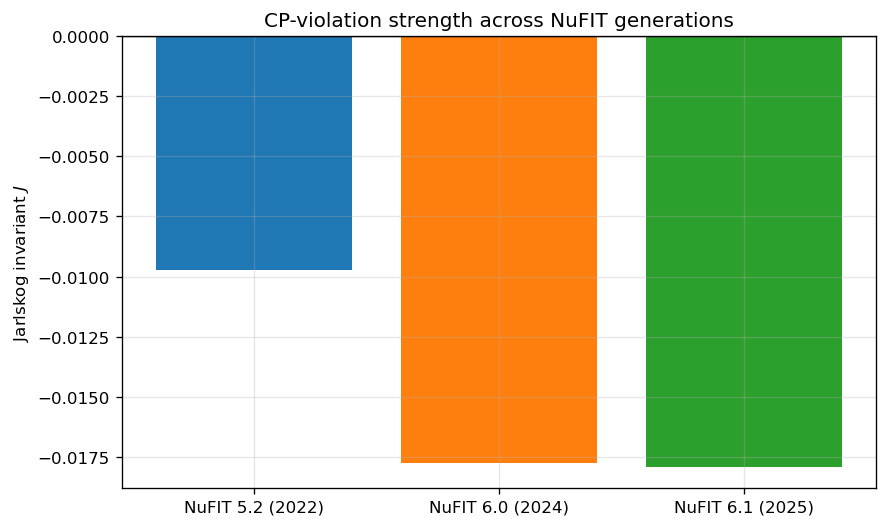

v:\output\diagnostic\core\diagnostic6_fig7_jarlskog_vs_generation.png
NuFIT 5.2 (2022): J = -0.00971
NuFIT 6.0 (2024): J = -0.01776
NuFIT 6.1 (2025): J = -0.01790


In [7]:
def jarlskog(theta12_deg, theta13_deg, theta23_deg, delta_deg):
    t12, t13, t23, d = (math.radians(v) for v in (theta12_deg, theta13_deg, theta23_deg, delta_deg))
    return 0.125 * math.sin(2 * t12) * math.sin(2 * t13) * math.sin(2 * t23) * math.cos(t13) * math.sin(d)


J_values = {
    name: jarlskog(
        OSCILLATION_PRESETS[name]["theta12_deg"],
        OSCILLATION_PRESETS[name]["theta13_deg"],
        OSCILLATION_PRESETS[name]["theta23_deg"],
        OSCILLATION_PRESETS[name]["delta13_deg"],
    )
    for name in PRESET_NAMES
}

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.bar([PRESET_LABELS[n] for n in PRESET_NAMES], [J_values[n] for n in PRESET_NAMES], color=[PRESET_COLORS[n] for n in PRESET_NAMES])
ax.axhline(0.0, color="black", lw=0.8)
ax.set_ylabel("Jarlskog invariant $J$")
ax.set_title("CP-violation strength across NuFIT generations")
ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()
save_and_show("diagnostic6_fig7_jarlskog_vs_generation.png", fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

for name in PRESET_NAMES:
    print(f"{PRESET_LABELS[name]:16s}: J = {J_values[name]:.5f}")

## 8. Summary

In [8]:
print("Summary - Core Diagnostic 6: NuFIT Oscillation Preset Comparison")
print("-" * 65)
for name in PRESET_NAMES:
    raw = OSCILLATION_PRESETS[name]
    print(f"{PRESET_LABELS[name]:16s} theta12={raw['theta12_deg']:.2f} theta13={raw['theta13_deg']:.2f} "
          f"theta23={raw['theta23_deg']:.2f} delta={raw['delta13_deg']:.1f} "
          f"DM21={raw['DeltamSq21']:.3e} DM3l={raw['DeltamSq3l']:+.3e} J={J_values[name]:.5f}")
print()
print(f"theta23 shift 5.2->6.0        : {theta23_shift:+.2f} deg (second octant -> near-maximal)")
print(f"Delta m^2_21 shift 5.2->6.1   : {rel_shift_dm21:+.4%} (largely from JUNO in 6.1)")
print()
print("At a DUNE-like benchmark (E=2000 MeV, L=1300 km), the resulting")
print("P(mu->mu)/P(mu->e) predictions differ measurably between NuFIT 5.2 and")
print("6.0/6.1, primarily tracking the theta23 shift; 6.0 and 6.1 predictions")
print("are close to each other, with the residual difference driven by the")
print("JUNO-era theta12/Delta m^2_21 update.")
print()
print("Pytest companion: tpeanuts.core.common.test (preset registry mechanics)")
print("Related notebook: notebooks/diagnostic/vacuum/diagnostic1_vacuum_propagation_flux.ipynb")

Summary - Core Diagnostic 6: NuFIT Oscillation Preset Comparison
-----------------------------------------------------------------
NuFIT 5.2 (2022) theta12=33.41 theta13=8.58 theta23=49.00 delta=197.0 DM21=7.410e-05 DM3l=+2.511e-03 J=-0.00971
NuFIT 6.0 (2024) theta12=33.68 theta13=8.56 theta23=43.30 delta=212.0 DM21=7.490e-05 DM3l=+2.513e-03 J=-0.01776
NuFIT 6.1 (2025) theta12=33.76 theta13=8.62 theta23=43.29 delta=212.0 DM21=7.537e-05 DM3l=+2.511e-03 J=-0.01790

theta23 shift 5.2->6.0        : -5.70 deg (second octant -> near-maximal)
Delta m^2_21 shift 5.2->6.1   : +1.7139% (largely from JUNO in 6.1)

At a DUNE-like benchmark (E=2000 MeV, L=1300 km), the resulting
P(mu->mu)/P(mu->e) predictions differ measurably between NuFIT 5.2 and
6.0/6.1, primarily tracking the theta23 shift; 6.0 and 6.1 predictions
are close to each other, with the residual difference driven by the
JUNO-era theta12/Delta m^2_21 update.

Pytest companion: tpeanuts.core.common.test (preset registry mechanics)
Rela